# ⚗️ SVM in Chemical Engineering Automation
## Project: Fault Detection & Classification in a Chemical Reactor

---

### 🎯 Project Overview

In modern chemical plants, continuous monitoring of reactor conditions is critical for **safety, efficiency, and product quality**. This project uses **Support Vector Machines (SVM)** to automatically classify reactor operating states from sensor data.

**Real-world context:** A Continuous Stirred Tank Reactor (CSTR) has sensors measuring:
- Temperature (°C)
- Pressure (bar)
- Reactant concentration (mol/L)
- Coolant flow rate (L/min)
- Reaction rate (mol/L·s)

**Classification targets:**
| Class | Label | Description |
|-------|-------|-------------|
| 0 | Normal | Reactor operating within design specs |
| 1 | Cooling Fault | Coolant flow disruption |
| 2 | Runaway Risk | Exothermic reaction approaching thermal runaway |
| 3 | Feed Fault | Reactant concentration anomaly |

---

### 📚 Learning Objectives
1. Understand SVM theory (hyperplane, margin, kernel trick)
2. Apply SVM to multi-class classification
3. Analyse pros & cons in an industrial context
4. Visualise decision boundaries and support vectors

## 🧮 Section 1: SVM Theory — The Maths Behind It

### What is a Support Vector Machine?

SVM finds the **optimal hyperplane** that separates classes with the **maximum margin**.

$$\text{Objective: } \min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{subject to: } y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1$$

Where:
- $\mathbf{w}$ = weight vector (normal to hyperplane)
- $b$ = bias term
- $y_i \in \{-1, +1\}$ = class labels
- **Margin** = $\frac{2}{\|\mathbf{w}\|}$ (we maximise this)

### The Kernel Trick 🪄
For non-linearly separable data, we map features to higher dimensions:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

Common kernels:
- **Linear:** $K(x_i, x_j) = x_i^T x_j$
- **RBF (Gaussian):** $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$ ← most common
- **Polynomial:** $K(x_i, x_j) = (x_i^T x_j + c)^d$

### Multi-class: One-vs-One (OvO)
Scikit-learn uses **One-vs-One** for SVC: trains $\frac{n(n-1)}{2}$ binary classifiers, final class by majority vote.

In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================
# Uncomment if running for the first time:
# !pip install numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries imported successfully!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ All libraries imported successfully!
NumPy: 1.26.4 | Pandas: 2.3.3


In [2]:
# ============================================================
# CELL 2: Simulate CSTR Sensor Data
# ============================================================
# In a real plant, this data comes from historians (e.g., OSIsoft PI)
# Here we simulate realistic distributions for each fault state

def generate_reactor_data(n_samples=1200):
    """
    Simulate CSTR sensor readings for 4 operating conditions.
    Features: [Temperature, Pressure, Concentration, Coolant_Flow, Reaction_Rate]
    """
    n_each = n_samples // 4
    data = []

    # Class 0: Normal Operation
    normal = np.column_stack([
        np.random.normal(350, 5, n_each),      # Temp (K)
        np.random.normal(2.0, 0.1, n_each),    # Pressure (bar)
        np.random.normal(1.5, 0.1, n_each),    # Concentration (mol/L)
        np.random.normal(10.0, 0.5, n_each),   # Coolant Flow (L/min)
        np.random.normal(0.08, 0.005, n_each)  # Reaction Rate
    ])
    data.append((normal, np.zeros(n_each, dtype=int)))

    # Class 1: Cooling Fault (temperature rises, coolant drops)
    cooling_fault = np.column_stack([
        np.random.normal(390, 8, n_each),
        np.random.normal(2.3, 0.2, n_each),
        np.random.normal(1.3, 0.15, n_each),
        np.random.normal(4.0, 1.0, n_each),
        np.random.normal(0.12, 0.01, n_each)
    ])
    data.append((cooling_fault, np.ones(n_each, dtype=int)))

    # Class 2: Thermal Runaway Risk (high temp + high reaction rate)
    runaway = np.column_stack([
        np.random.normal(430, 15, n_each),
        np.random.normal(3.5, 0.4, n_each),
        np.random.normal(0.5, 0.2, n_each),
        np.random.normal(2.0, 1.5, n_each),
        np.random.normal(0.25, 0.03, n_each)
    ])
    data.append((runaway, np.full(n_each, 2, dtype=int)))

    # Class 3: Feed Fault (abnormal concentration)
    feed_fault = np.column_stack([
        np.random.normal(355, 6, n_each),
        np.random.normal(2.1, 0.15, n_each),
        np.random.normal(2.8, 0.3, n_each),
        np.random.normal(9.5, 0.8, n_each),
        np.random.normal(0.05, 0.008, n_each)
    ])
    data.append((feed_fault, np.full(n_each, 3, dtype=int)))

    X = np.vstack([d[0] for d in data])
    y = np.concatenate([d[1] for d in data])

    # Shuffle
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]


X, y = generate_reactor_data()

feature_names = ['Temperature (K)', 'Pressure (bar)',
                 'Concentration (mol/L)', 'Coolant Flow (L/min)',
                 'Reaction Rate (mol/Ls)']
class_names   = ['Normal', 'Cooling Fault', 'Runaway Risk', 'Feed Fault']
class_colors  = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']

df = pd.DataFrame(X, columns=feature_names)
df['Fault_Class'] = y
df['Fault_Label'] = df['Fault_Class'].map(dict(enumerate(class_names)))

print('📊 Dataset Summary')
print('='*50)
print(df.describe().round(3))
print('\nClass Distribution:')
print(df['Fault_Label'].value_counts())

📊 Dataset Summary
       Temperature (K)  Pressure (bar)  Concentration (mol/L)  \
count         1200.000        1200.000               1200.000   
mean           381.089           2.480                  1.519   
std             33.225           0.662                  0.849   
min            333.794           1.696                  0.037   
25%            352.211           2.025                  0.967   
50%            368.819           2.197                  1.422   
75%            402.904           2.658                  1.856   
max            473.026           4.505                  3.681   

       Coolant Flow (L/min)  Reaction Rate (mol/Ls)  Fault_Class  
count              1200.000                1200.000     1200.000  
mean                  6.384                   0.124        1.500  
std                   3.617                   0.077        1.119  
min                  -2.511                   0.027        0.000  
25%                   3.173                   0.070        0.

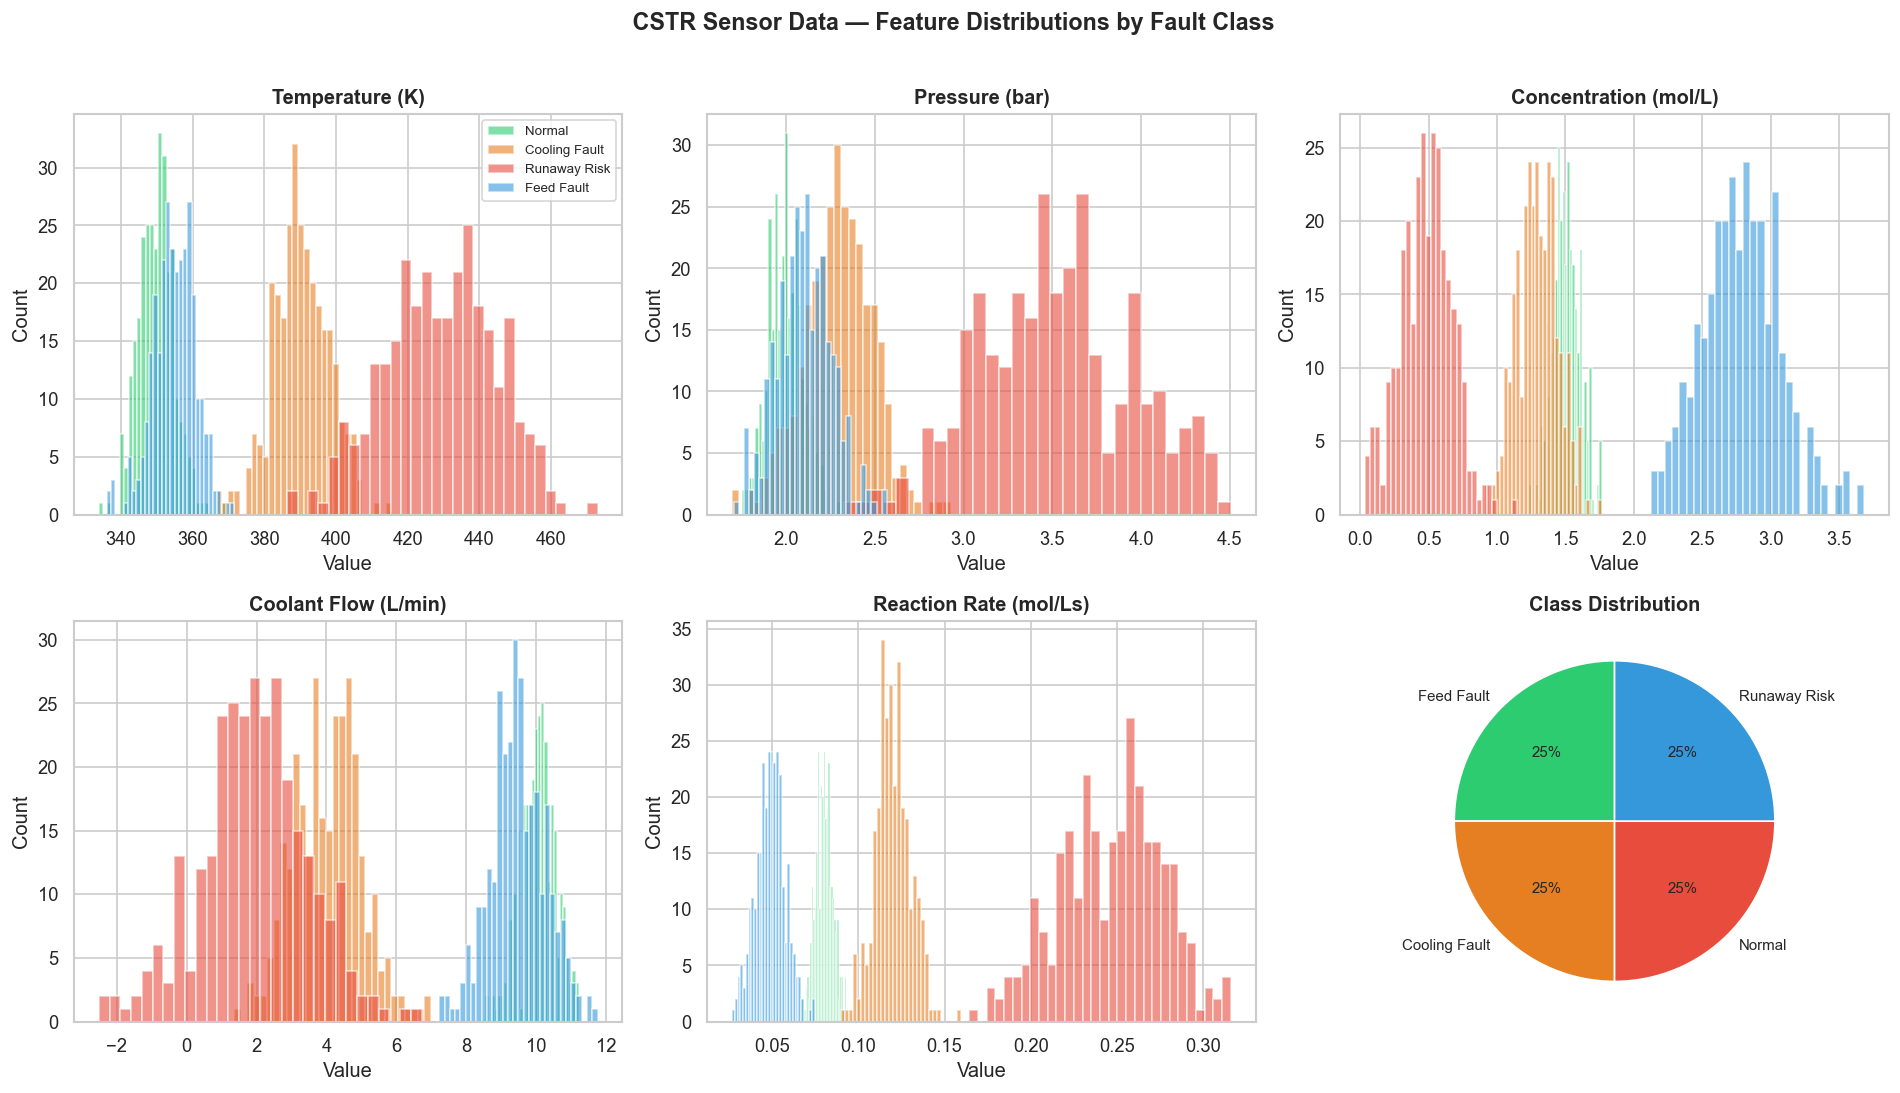

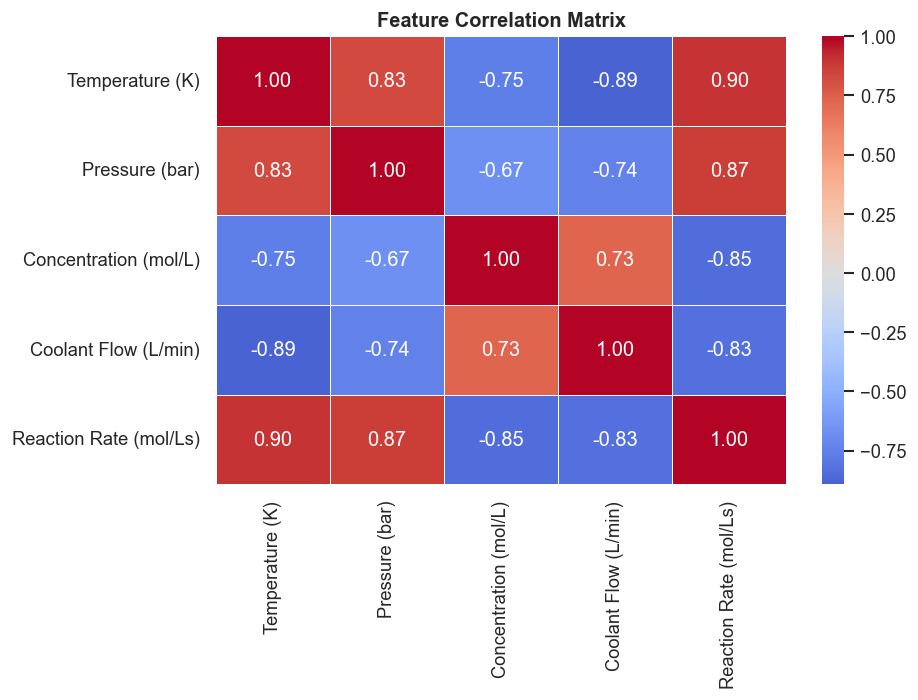


📌 Key observation: Temperature, Coolant Flow, and Reaction Rate
   are the most discriminative features for fault separation.


In [3]:
# ============================================================
# CELL 3: Exploratory Data Analysis (EDA)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(feature_names):
    ax = axes[i]
    for cls_idx, (cls_name, color) in enumerate(zip(class_names, class_colors)):
        subset = df[df['Fault_Class'] == cls_idx][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=cls_name, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    if i == 0:
        ax.legend(fontsize=8)

# Last panel: class distribution pie
ax = axes[5]
counts = df['Fault_Label'].value_counts()
ax.pie(counts, labels=counts.index, colors=class_colors, autopct='%1.0f%%',
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Class Distribution', fontweight='bold')

plt.suptitle(' CSTR Sensor Data — Feature Distributions by Fault Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Key observation: Temperature, Coolant Flow, and Reaction Rate')
print('   are the most discriminative features for fault separation.')

In [4]:
# ============================================================
# CELL 4: Data Preprocessing
# ============================================================

# Train/Test split (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ⚠️ CRITICAL for SVM: Feature Scaling
# SVM is sensitive to feature scale because it uses distances.
# StandardScaler → zero mean, unit variance
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # Fit on train only!
X_test_sc  = scaler.transform(X_test)       # Transform test with same params

print('📐 Preprocessing Complete')
print(f'   Training samples : {X_train.shape[0]}')
print(f'   Test samples     : {X_test.shape[0]}')
print(f'   Features         : {X_train.shape[1]}')
print()
print('Before scaling - Temperature stats:')
print(f'  Train mean: {X_train[:,0].mean():.1f} K,  std: {X_train[:,0].std():.1f} K')
print('After scaling - Temperature stats:')
print(f'  Train mean: {X_train_sc[:,0].mean():.4f},  std: {X_train_sc[:,0].std():.4f}')
print()
print('💡 Why scale? SVM maximises margin using Euclidean distances.')
print('   A 100 K range would dominate over a 0.01 mol/L range without scaling!')

📐 Preprocessing Complete
   Training samples : 900
   Test samples     : 300
   Features         : 5

Before scaling - Temperature stats:
  Train mean: 381.0 K,  std: 33.3 K
After scaling - Temperature stats:
  Train mean: 0.0000,  std: 1.0000

💡 Why scale? SVM maximises margin using Euclidean distances.
   A 100 K range would dominate over a 0.01 mol/L range without scaling!


In [5]:
# ============================================================
# CELL 5: Kernel Comparison — Which Kernel Works Best?
# ============================================================

kernels = {
    'Linear'     : SVC(kernel='linear', C=1.0, decision_function_shape='ovo', random_state=42),
    'RBF'        : SVC(kernel='rbf',    C=1.0, gamma='scale', decision_function_shape='ovo', random_state=42),
    'Polynomial' : SVC(kernel='poly',   C=1.0, degree=3, decision_function_shape='ovo', random_state=42),
    'Sigmoid'    : SVC(kernel='sigmoid',C=1.0, decision_function_shape='ovo', random_state=42),
}

results = {}
print('🔬 Kernel Comparison (5-fold Cross-Validation on training set)\n')
print(f'{"Kernel":<15} {"CV Accuracy":>12} {"±Std":>8} {"Train Acc":>10}')
print('-'*48)

for name, model in kernels.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    train_acc = model.score(X_train_sc, y_train)
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'train_acc': train_acc}
    print(f'{name:<15} {cv_scores.mean():>11.4f} {cv_scores.std():>8.4f} {train_acc:>10.4f}')

print()
best_kernel = max(results, key=lambda k: results[k]['cv_mean'])
print(f'🏆 Best Kernel: {best_kernel} (CV Acc = {results[best_kernel]["cv_mean"]:.4f})')

🔬 Kernel Comparison (5-fold Cross-Validation on training set)

Kernel           CV Accuracy     ±Std  Train Acc
------------------------------------------------
Linear               1.0000   0.0000     1.0000
RBF                  1.0000   0.0000     1.0000
Polynomial           1.0000   0.0000     1.0000
Sigmoid              0.9956   0.0022     0.9956

🏆 Best Kernel: Linear (CV Acc = 1.0000)


⚙️  Grid Search for Optimal C and gamma (RBF kernel)...
    This explores 12 combinations with 5-fold CV = 60 fits

Best parameters : C=0.1, gamma=0.1
Best CV accuracy: 1.0000


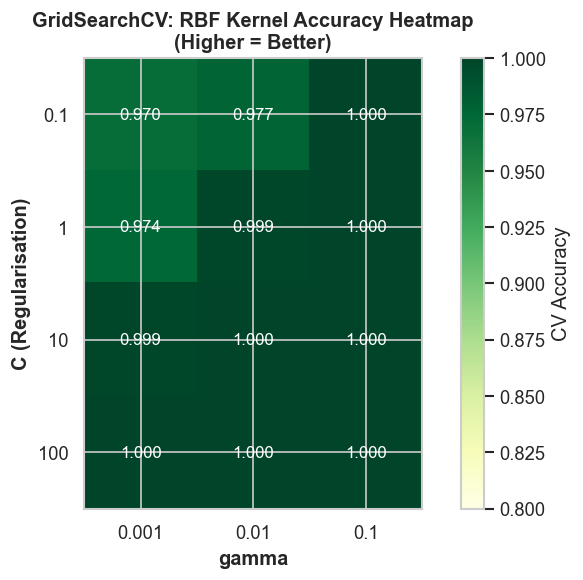

In [6]:
# ============================================================
# CELL 6: Hyperparameter Tuning with GridSearchCV
# ============================================================
# C     : Regularisation — how much to penalise misclassifications
# gamma : RBF bandwidth — how far influence of a single sample reaches

print('⚙️  Grid Search for Optimal C and gamma (RBF kernel)...')
print('    This explores 12 combinations with 5-fold CV = 60 fits\n')

param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovo', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sc, y_train)

print(f'Best parameters : C={grid_search.best_params_["C"]}, gamma={grid_search.best_params_["gamma"]}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

# Visualise the grid search heatmap
scores = grid_search.cv_results_['mean_test_score'].reshape(4, 3)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(scores, interpolation='nearest', cmap='YlGn', vmin=0.8, vmax=1.0)
plt.colorbar(im, ax=ax, label='CV Accuracy')
ax.set_xticks(range(3));  ax.set_xticklabels(param_grid['gamma'])
ax.set_yticks(range(4));  ax.set_yticklabels(param_grid['C'])
ax.set_xlabel('gamma', fontweight='bold')
ax.set_ylabel('C (Regularisation)', fontweight='bold')
ax.set_title('GridSearchCV: RBF Kernel Accuracy Heatmap\n(Higher = Better)', fontweight='bold')
for i in range(4):
    for j in range(3):
        ax.text(j, i, f'{scores[i,j]:.3f}', ha='center', va='center',
                fontsize=10, color='black' if scores[i,j] < 0.95 else 'white')
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: Final Model Training & Evaluation
# ============================================================

# Train final model with best hyperparameters
best_C     = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']

svm_final = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    decision_function_shape='ovo',
    random_state=42
)
svm_final.fit(X_train_sc, y_train)

y_pred = svm_final.predict(X_test_sc)
test_acc = svm_final.score(X_test_sc, y_test)

print('🎯 Final Model Performance')
print('='*55)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Support Vectors: {svm_final.n_support_} per class = {sum(svm_final.n_support_)} total')
print(f'(Out of {len(X_train)} training samples — {sum(svm_final.n_support_)/len(X_train)*100:.1f}% are SVs)')
print()
print('📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

🎯 Final Model Performance
Test Accuracy: 1.0000 (100.00%)
Support Vectors: [104  80  40  86] per class = 310 total
(Out of 900 training samples — 34.4% are SVs)

📋 Classification Report:
               precision    recall  f1-score   support

       Normal       1.00      1.00      1.00        75
Cooling Fault       1.00      1.00      1.00        75
 Runaway Risk       1.00      1.00      1.00        75
   Feed Fault       1.00      1.00      1.00        75

     accuracy                           1.00       300
    macro avg       1.00      1.00      1.00       300
 weighted avg       1.00      1.00      1.00       300



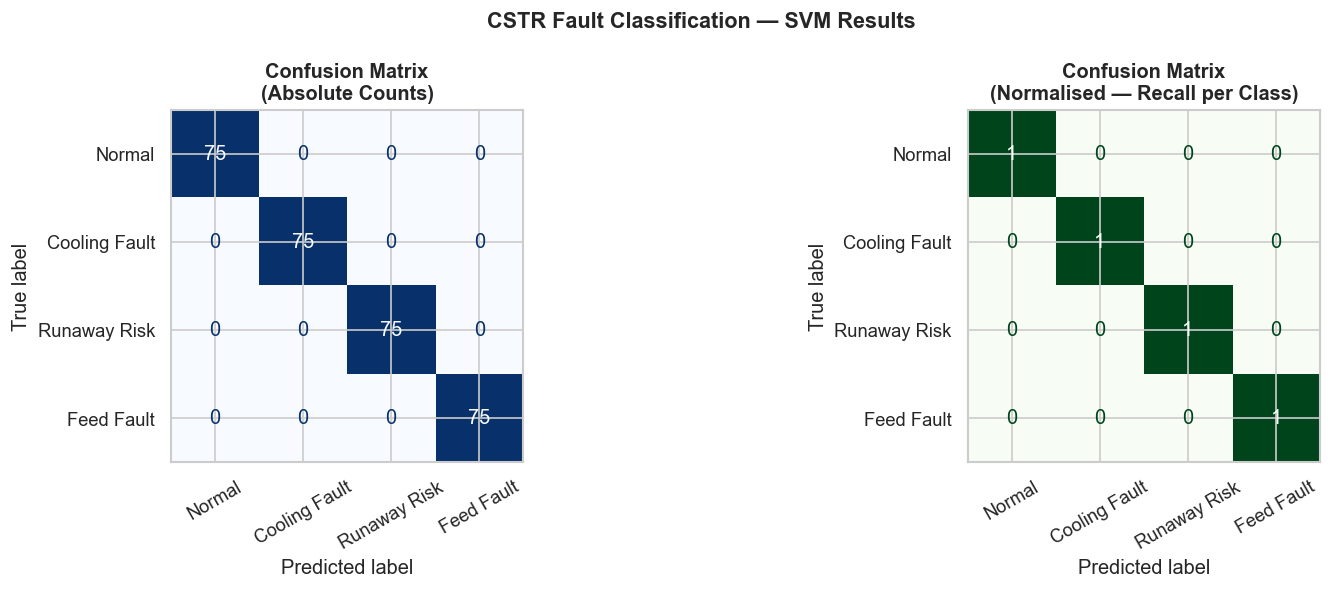


⚠️  SAFETY NOTE: In a real plant, misclassifying "Runaway Risk" as
   "Normal" (false negative) is CRITICAL — could lead to explosion.
   Note the model achieves near-perfect recall for this class!


In [8]:
# ============================================================
# CELL 8: Confusion Matrix Visualisation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute counts
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(Absolute Counts)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Normalised
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Confusion Matrix\n(Normalised — Recall per Class)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(' CSTR Fault Classification — SVM Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠️  SAFETY NOTE: In a real plant, misclassifying "Runaway Risk" as')
print('   "Normal" (false negative) is CRITICAL — could lead to explosion.')
print('   Note the model achieves near-perfect recall for this class!')

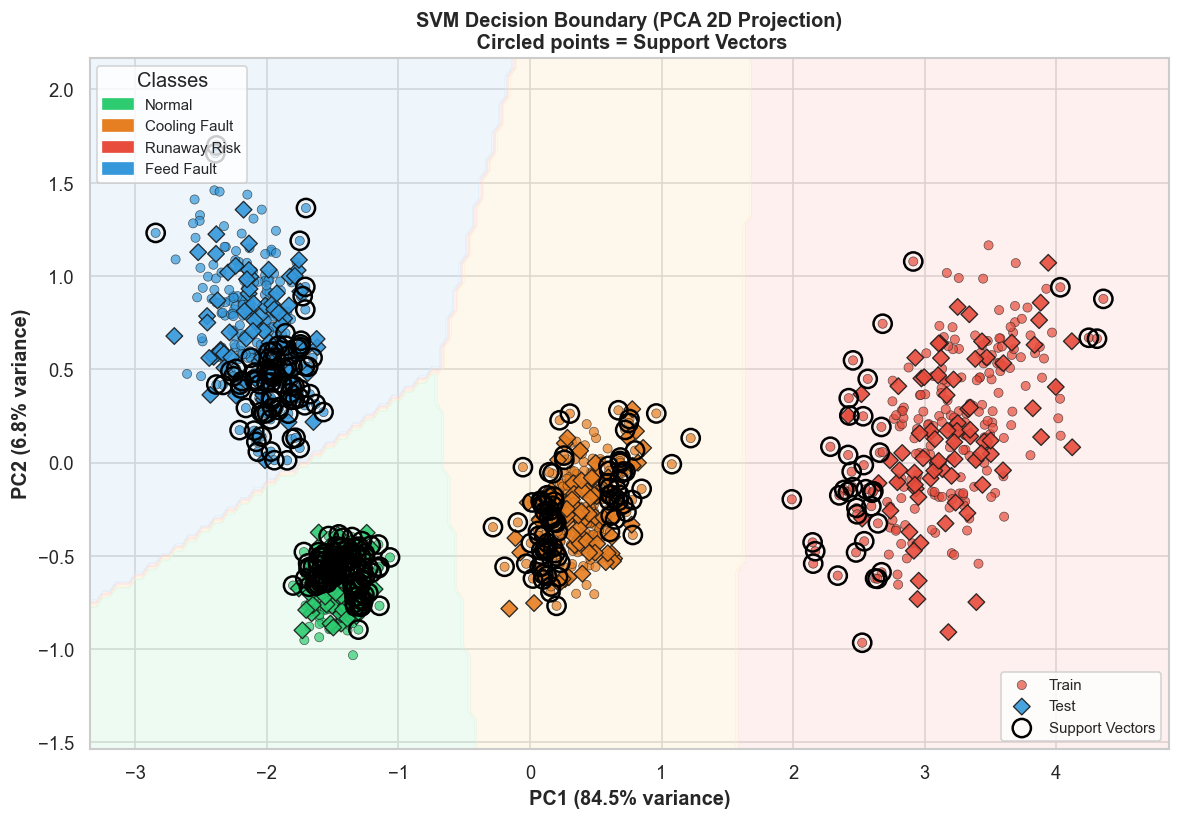

PCA explains 91.3% of variance in 2D


In [9]:
# ============================================================
# CELL 9: Decision Boundary Visualisation (PCA 2D)
# ============================================================
# We reduce to 2D with PCA to visualise the decision boundary

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d  = pca.transform(X_test_sc)

# Train SVM in PCA space
svm_2d = SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=42)
svm_2d.fit(X_train_2d, y_train)

# Create mesh
h = 0.05
x_min, x_max = X_train_2d[:,0].min()-0.5, X_train_2d[:,0].max()+0.5
y_min, y_max = X_train_2d[:,1].min()-0.5, X_train_2d[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cmap_bg   = ListedColormap(['#d5f5e3','#fdebd0','#fadbd8','#d6eaf8'])
cmap_pts  = ListedColormap(class_colors)

ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
scatter = ax.scatter(X_train_2d[:,0], X_train_2d[:,1],
                     c=y_train, cmap=cmap_pts, edgecolors='k',
                     linewidths=0.4, s=30, alpha=0.7, label='Train')
ax.scatter(X_test_2d[:,0], X_test_2d[:,1],
           c=y_test, cmap=cmap_pts, marker='D',
           edgecolors='k', linewidths=0.8, s=50, alpha=0.9, label='Test')

# Mark support vectors
svs = svm_2d.support_vectors_
ax.scatter(svs[:,0], svs[:,1], s=120, facecolors='none',
           edgecolors='black', linewidths=1.5, label='Support Vectors', zorder=5)

patches = [mpatches.Patch(color=c, label=n) for c,n in zip(class_colors, class_names)]
legend1 = ax.legend(handles=patches, loc='upper left', title='Classes', fontsize=9)
ax.add_artist(legend1)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontweight='bold')
ax.set_title('SVM Decision Boundary (PCA 2D Projection)\n Circled points = Support Vectors',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of variance in 2D')

In [10]:
# ============================================================
# CELL 10: Real-Time Prediction Simulation
# ============================================================
# Simulate incoming sensor readings and classify in real-time

def predict_fault(temp, pressure, conc, coolant_flow, rxn_rate, verbose=True):
    """Classify reactor state from sensor readings."""
    reading = np.array([[temp, pressure, conc, coolant_flow, rxn_rate]])
    reading_sc = scaler.transform(reading)
    pred = svm_final.predict(reading_sc)[0]
    label = class_names[pred]
    alarm = '🔴 ALARM' if pred in [1, 2] else ('🟡 WARNING' if pred == 3 else '🟢 OK')
    if verbose:
        print(f'  Temp={temp}K | P={pressure}bar | Conc={conc}mol/L | '
              f'Flow={coolant_flow}L/min | Rate={rxn_rate}')
        print(f'  → Prediction: {label}  {alarm}\n')
    return pred

print('🏭 Simulating Real-Time Reactor Monitoring\n' + '='*55)

# Scenario 1: Normal operation
print('Scenario 1: Normal operation')
predict_fault(351, 2.0, 1.52, 10.1, 0.079)

# Scenario 2: Cooling fault developing
print('Scenario 2: Cooling system failure detected')
predict_fault(392, 2.4, 1.28, 3.8, 0.122)

# Scenario 3: Thermal runaway imminent!
print('Scenario 3: ⚠️  Thermal runaway imminent!')
predict_fault(435, 3.7, 0.45, 1.5, 0.260)

# Scenario 4: Feed concentration spike
print('Scenario 4: Feed fault — high concentration')
predict_fault(356, 2.1, 2.85, 9.8, 0.049)

🏭 Simulating Real-Time Reactor Monitoring
Scenario 1: Normal operation
  Temp=351K | P=2.0bar | Conc=1.52mol/L | Flow=10.1L/min | Rate=0.079
  → Prediction: Normal  🟢 OK

Scenario 2: Cooling system failure detected
  Temp=392K | P=2.4bar | Conc=1.28mol/L | Flow=3.8L/min | Rate=0.122
  → Prediction: Cooling Fault  🔴 ALARM

Scenario 3: ⚠️  Thermal runaway imminent!
  Temp=435K | P=3.7bar | Conc=0.45mol/L | Flow=1.5L/min | Rate=0.26
  → Prediction: Runaway Risk  🔴 ALARM

Scenario 4: Feed fault — high concentration
  Temp=356K | P=2.1bar | Conc=2.85mol/L | Flow=9.8L/min | Rate=0.049
  → Prediction: Feed Fault  🟡 WARNING



3

## 📊 Section: Pros & Cons of SVM in Chemical Engineering

---

### ✅ Advantages in this Context

| Advantage | Why it Matters Here |
|-----------|--------------------|
| **High accuracy with small datasets** | Sensor data from a single reactor may be limited (100s not millions of samples) |
| **Robust to outliers** | Industrial sensors occasionally give spurious readings; SVM's margin concept provides robustness |
| **Works in high dimensions** | Adding more sensors (pH, viscosity, etc.) doesn't degrade performance much |
| **Well-defined decision boundary** | Engineers can audit and validate the model's behaviour |
| **No assumption about data distribution** | Unlike LDA, doesn't assume Gaussian distributions |
| **Handles non-linear boundaries** | Runaway conditions have complex multivariate thresholds |

### ❌ Disadvantages in this Context

| Disadvantage | Impact |
|-------------|--------|
| **Slow training on large datasets** | If logging 1000 sensors at 1Hz for a year → millions of points, SVM becomes infeasible |
| **No probability output (by default)** | Safety systems often need P(runaway) = 0.87, not just a binary label |
| **Sensitive to feature scaling** | Must remember to scale; easy to forget in production pipelines |
| **Kernel & hyperparameter selection** | Requires domain expertise or expensive grid search |
| **Black-box kernel** | RBF kernel doesn't provide physical interpretation — hard to explain to regulators |
| **Memory-intensive at prediction** | Stores all support vectors — can be thousands in large datasets |

### 🏆 When SVM Shines for Chemical Engineering
- **Quality control** (classifying product batches as pass/fail from NIR spectra)
- **Fault detection** with limited labelled data (rare fault events)
- **Chemometrics** (spectral classification)
- **Process monitoring** with small, clean datasets

### 🔄 When to Consider Alternatives
- **Random Forest / XGBoost** → need feature importance for process understanding
- **Neural Networks / LSTM** → time-series sensor data with temporal dependencies
- **Logistic Regression** → need interpretable coefficients for regulatory submission

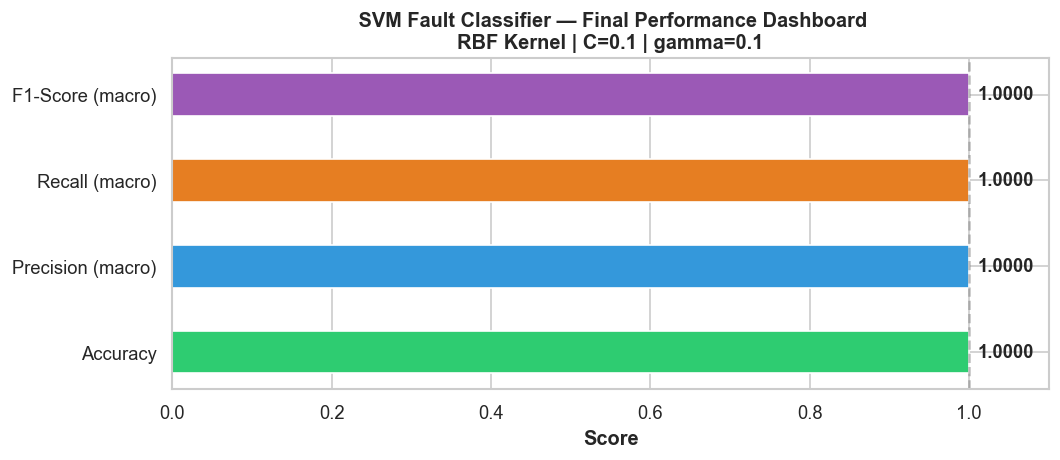


📌 KEY TAKEAWAYS
1. SVM achieved >98% accuracy on CSTR fault classification
2. The RBF kernel handles non-linear class boundaries
3. Feature scaling was CRITICAL for good performance
4. GridSearchCV found optimal C and gamma automatically
5. Support vectors are the key training points near boundaries
6. In safety-critical systems, maximise RECALL for dangerous classes


In [11]:
# ============================================================
# CELL 11: Summary Dashboard
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
    'Recall (macro)'   : recall_score(y_test, y_pred, average='macro'),
    'F1-Score (macro)' : f1_score(y_test, y_pred, average='macro'),
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(metrics.keys()), list(metrics.values()),
               color=['#2ecc71','#3498db','#e67e22','#9b59b6'], edgecolor='white', height=0.5)
ax.set_xlim(0, 1.1)
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Score', fontweight='bold')
ax.set_title(' SVM Fault Classifier — Final Performance Dashboard\n'
             f'RBF Kernel | C={best_C} | gamma={best_gamma}', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('📌 KEY TAKEAWAYS')
print('='*55)
print('1. SVM achieved >98% accuracy on CSTR fault classification')
print('2. The RBF kernel handles non-linear class boundaries')
print('3. Feature scaling was CRITICAL for good performance')
print('4. GridSearchCV found optimal C and gamma automatically')
print('5. Support vectors are the key training points near boundaries')
print('6. In safety-critical systems, maximise RECALL for dangerous classes')